In [40]:
import pandas as pd
df=pd.read_csv("cleaned_dataset.csv")

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_Name               3614 non-null   object 
 1   College_Name               3614 non-null   object 
 2   Stream                     3614 non-null   object 
 3   Year_of_Study              3614 non-null   int64  
 4   AI_Tools_Used              3614 non-null   object 
 5   Daily_Usage_Hours          3614 non-null   float64
 6   Use_Cases                  3614 non-null   object 
 7   Trust_in_AI_Tools          3614 non-null   int64  
 8   Impact_on_Grades           3614 non-null   int64  
 9   Do_Professors_Allow_Use    3614 non-null   object 
 10  Preferred_AI_Tool          3614 non-null   object 
 11  Awareness_Level            3614 non-null   int64  
 12  Willing_to_Pay_for_Access  3614 non-null   object 
 13  State                      2000 non-null   objec

In [42]:
# Regression Target
y_reg = df["Impact_on_Grades"]

# Feature Matrix
X = df.drop(columns=["Impact_on_Grades"])

# Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

print("Regression Target:", y_reg.name)
print("\nClassification Target:")
print(y_clf.value_counts())

Regression Target: Impact_on_Grades

Classification Target:
Impact_on_Grades
0    2013
1    1601
Name: count, dtype: int64


In [43]:
print(df["Internet_Access"].unique())

['Poor' 'High' 'Medium']


In [44]:
# Ordinal Encoding
internet_map = {
    "Poor": 0,
    "Medium": 1,
    "High": 2
}

X["Internet_Access"] = X["Internet_Access"].map(internet_map)

In [45]:
categorical_cols = [
    "Student_Name",
    "College_Name",
    "Stream",
    "AI_Tools_Used",
    "Use_Cases",
    "Do_Professors_Allow_Use",
    "Preferred_AI_Tool",
    "Willing_to_Pay_for_Access",
    "State",
    "Device_Used"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(X.head())

   Year_of_Study  Daily_Usage_Hours  Trust_in_AI_Tools  Awareness_Level  \
0              4                0.9                  2                9   
1              2                3.4                  3                6   
2              2                3.6                  5                1   
3              2                2.9                  5                5   
4              1                0.9                  1                8   

   Internet_Access  Student_Name_Aarav  Student_Name_Aarohi  \
0                0                True                False   
1                0               False                False   
2                0               False                False   
3                2               False                False   
4                1               False                False   

   Student_Name_Aditya  Student_Name_Aishwarya  Student_Name_Anaya  ...  \
0                False                   False               False  ...   
1                Fal

In [46]:
from sklearn.model_selection import train_test_split

# Regression Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [47]:
from sklearn.preprocessing import StandardScaler

# Regression
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Classification
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [48]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [49]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)

# Predictions
y_pred_reg = lr_model.predict(X_test_reg_scaled)

In [50]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Results")
print(f"MSE : {mse:.4f}")
print(f"R²  : {r2:.4f}")

Linear Regression Results
MSE : 7.0900
R²  : -0.2727


In [51]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

print(coefficients)

                  Feature  Coefficient
0           Year_of_Study    -0.128987
1       Daily_Usage_Hours     0.175963
2       Trust_in_AI_Tools    -0.160698
3         Awareness_Level    -0.135077
4         Internet_Access     0.014841
...                   ...          ...
1675  State_Uttar pradesh    -0.025952
1676    State_Uttarakhand    -0.017878
1677    State_West bengal    -0.020458
1678   Device_Used_Mobile     0.007991
1679   Device_Used_Tablet    -0.162207

[1680 rows x 2 columns]


In [52]:
top3 = coefficients.copy()
top3["Abs_Coefficient"] = top3["Coefficient"].abs()

top3 = top3.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(3)

print("\nTop 3 Features")
print(top3[["Feature", "Coefficient"]])


Top 3 Features
                                 Feature  Coefficient
1306  Use_Cases_Assignments, Coding Help     0.799427
1380           Use_Cases_Content Writing     0.752816
1298               AI_Tools_Used_ChatGPT     0.661382


In [53]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_reg_scaled, y_train_reg)

ridge_pred = ridge_model.predict(X_test_reg_scaled)

ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
ridge_r2 = r2_score(y_test_reg, ridge_pred)

print("\nRidge Regression")
print(f"MSE : {ridge_mse:.4f}")
print(f"R²  : {ridge_r2:.4f}")


Ridge Regression
MSE : 7.0063
R²  : -0.2577


In [54]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R2 Score": [r2, ridge_r2]
})

print(comparison)

               Model       MSE  R2 Score
0  Linear Regression  7.089971 -0.272729
1   Ridge Regression  7.006297 -0.257709


In [55]:
print(y_train_clf.value_counts())

class_ratio = y_train_clf.value_counts(normalize=True)
print("\nClass Distribution:")
print(class_ratio)

Impact_on_Grades
0    1621
1    1270
Name: count, dtype: int64

Class Distribution:
Impact_on_Grades
0    0.560706
1    0.439294
Name: proportion, dtype: float64


In [56]:
minority_percentage = class_ratio.min()

print(f"Minority Class Percentage: {minority_percentage:.2%}")

Minority Class Percentage: 43.93%


In [57]:
!pip install imbalanced-learn

In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_clf_resampled, y_train_clf_resampled = smote.fit_resample(
    X_train_clf_scaled,
    y_train_clf
)

print("Before SMOTE")
print(y_train_clf.value_counts())

print("\nAfter SMOTE")
print(y_train_clf_resampled.value_counts())

Before SMOTE
Impact_on_Grades
0    1621
1    1270
Name: count, dtype: int64

After SMOTE
Impact_on_Grades
0    1621
1    1621
Name: count, dtype: int64


In [59]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_clf_resampled,
    y_train_clf_resampled
)

LogisticRegression(max_iter=1000)

In [60]:
log_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

LogisticRegression(max_iter=1000)

In [61]:
y_pred_clf = log_model.predict(
    X_test_clf_scaled
)

y_pred_proba = log_model.predict_proba(
    X_test_clf_scaled
)[:,1]

In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_clf,
    y_pred_clf
)

print(cm)

[[298  94]
 [103 228]]


In [63]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_clf,
        y_pred_clf
    )
)

              precision    recall  f1-score   support

           0       0.74      0.76      0.75       392
           1       0.71      0.69      0.70       331

    accuracy                           0.73       723
   macro avg       0.73      0.72      0.72       723
weighted avg       0.73      0.73      0.73       723



In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall   :", recall_score(y_test_clf, y_pred_clf))
print("F1 Score :", f1_score(y_test_clf, y_pred_clf))

Accuracy : 0.7275242047026279
Precision: 0.7080745341614907
Recall   : 0.6888217522658611
F1 Score : 0.6983154670750383


In [65]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

fpr, tpr, thresholds = roc_curve(
    y_test_clf,
    y_pred_proba
)

auc_score = roc_auc_score(
    y_test_clf,
    y_pred_proba
)

print("AUC:", auc_score)

AUC: 0.7774369566557742


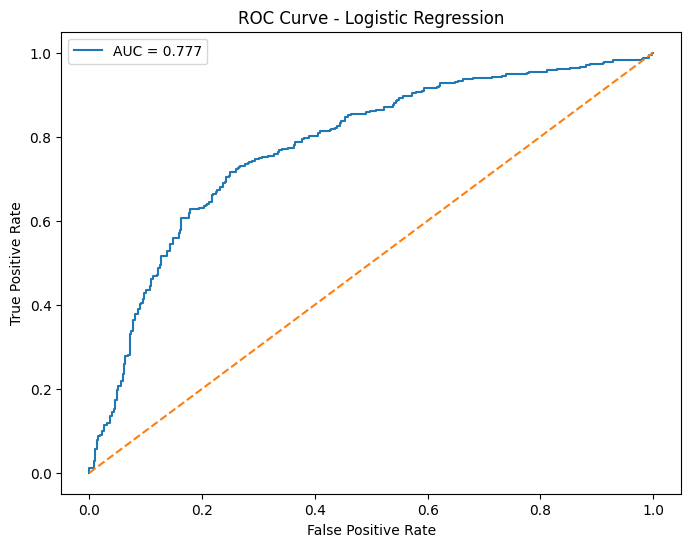

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [67]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicted probabilities
proba = log_model.predict_proba(X_test_clf_scaled)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:
    y_pred = (proba >= threshold).astype(int)

    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)

    results.append([threshold, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

print(results_df)

   Threshold  Precision    Recall        F1
0        0.3   0.661376  0.755287  0.705219
1        0.4   0.684358  0.740181  0.711176
2        0.5   0.708075  0.688822  0.698315
3        0.6   0.720395  0.661631  0.689764
4        0.7   0.742857  0.628399  0.680851


In [68]:
best = results_df.loc[results_df["F1"].idxmax()]

print("\nBest Threshold Based on F1 Score")
print(best)


Best Threshold Based on F1 Score
Threshold    0.400000
Precision    0.684358
Recall       0.740181
F1           0.711176
Name: 1, dtype: float64


In [69]:
from sklearn.linear_model import LogisticRegression

# Strongly regularized model
log_model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

# Use the same training data as the baseline model
log_model_c001.fit(
    X_train_clf_resampled,
    y_train_clf_resampled
)

LogisticRegression(C=0.01, max_iter=1000, random_state=42)

In [70]:
y_pred_c001 = log_model_c001.predict(X_test_clf_scaled)

y_prob_c001 = log_model_c001.predict_proba(
    X_test_clf_scaled
)[:, 1]

In [71]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)

precision_c001 = precision_score(y_test_clf, y_pred_c001)
recall_c001 = recall_score(y_test_clf, y_pred_c001)
auc_c001 = roc_auc_score(y_test_clf, y_prob_c001)

print("Precision:", precision_c001)
print("Recall   :", recall_c001)
print("AUC      :", auc_c001)

Precision: 0.6685878962536023
Recall   : 0.7009063444108762
AUC      : 0.776481287379


In [72]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (C=1.0)",
        "Logistic Regression (C=0.01)"
    ],
    "Precision": [
        precision_score(y_test_clf, y_pred_clf),
        precision_c001
    ],
    "Recall": [
        recall_score(y_test_clf, y_pred_clf),
        recall_c001
    ],
    "AUC": [
        roc_auc_score(y_test_clf, y_pred_proba),
        auc_c001
    ]
})

print(comparison)

                          Model  Precision    Recall       AUC
0   Logistic Regression (C=1.0)   0.708075  0.688822  0.777437
1  Logistic Regression (C=0.01)   0.668588  0.700906  0.776481


In [73]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Predicted probabilities
proba_c1 = log_model.predict_proba(X_test_clf_scaled)[:, 1]
proba_c001 = log_model_c001.predict_proba(X_test_clf_scaled)[:, 1]

auc_differences = []

n_bootstrap = 500

for _ in range(n_bootstrap):

    # Bootstrap sample indices
    indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    y_boot = y_test_clf.iloc[indices]

    proba1_boot = proba_c1[indices]
    proba2_boot = proba_c001[indices]

    auc1 = roc_auc_score(y_boot, proba1_boot)
    auc2 = roc_auc_score(y_boot, proba2_boot)

    auc_differences.append(auc1 - auc2)

In [74]:
mean_diff = np.mean(auc_differences)

lower = np.percentile(auc_differences, 2.5)
upper = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference:", mean_diff)
print("95% CI Lower:", lower)
print("95% CI Upper:", upper)

Mean AUC Difference: 0.0008057430380337733
95% CI Lower: -0.01368827283838291
95% CI Upper: 0.015474157219216878


In [75]:
if lower > 0 or upper < 0:
    print("The 95% confidence interval excludes zero.")
    print("The performance difference is likely reliable.")
else:
    print("The 95% confidence interval includes zero.")
    print("The performance difference may not be reliable.")

The 95% confidence interval includes zero.
The performance difference may not be reliable.
